# Creating a Custom Visualizer in pyRDDLGym

In this notebook, we show how to create a custom visualizer for a domain that does not have an existing domain-specific visualizer.

First, install the required packages:

In [1]:
%pip install --quiet --upgrade pip
%pip install --quiet pyRDDLGym rddlrepository

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


Next, import the required packages:

In [1]:
import os
from IPython.display import Image as IPyImage
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

import pyRDDLGym
from pyRDDLGym.core.policy import RandomAgent
from pyRDDLGym.core.visualizer.movie import MovieGenerator
from pyRDDLGym.core.visualizer.viz import BaseViz

Let us load the Sudoku domain from the arcade context. Note, this domain does not have a custom visualizer and defaults to a generic chart visualizer which may not suffice for debugging:

In [2]:
env = pyRDDLGym.make('Sudoku_arcade', '0')
print(env._visualizer)

We proceed to create a customized visualization environment for this domain. 

To do so, we must first subclass the ``BaseViz`` class located in ``pyRDDLGym.core.visualizer.viz``. The ``render`` function must be overriden.

The Sudoku domain consists of numbers arranged in a 2D grid. The row and column objects are ``brow`` and ``bcol``, respectively. The state has elements of the form ``board___r__c`` where (r, c) are the row-col coordinates. We will use pyplot to draw this grid of numbers:

In [3]:
class SudokuViz(BaseViz):
    
    def __init__(self, model):
        # must be initialized with the model to access the object names for rendering
        self._rows = model.type_to_objects['brow']
        self._cols = model.type_to_objects['bcol']
        
    def render(self, state):

        # create the figure
        fig = plt.figure(figsize=(len(self._cols), len(self._rows)))
        ax = plt.gca()
        ax.set_xlim(0, len(self._cols))
        ax.set_ylim(0, len(self._rows))
        
        # draw the board values        
        for i, row_obj in enumerate(self._rows):
            for j, col_obj in enumerate(self._cols):
                x_coord = j + 0.5
                y_coord = len(self._rows) - i - 0.5
                fluent = f'board___{row_obj}__{col_obj}'
                ax.text(x_coord, y_coord, state[fluent], ha='center', va='center', fontsize=12)
        ax.set_xticklabels([]); ax.set_yticklabels([])

        # convert to numpy image pixel array
        # (required to maintain interoperability with any viz tool and pyRDDLGym)
        ax.set_position((0, 0, 1, 1))
        fig.canvas.draw()
        data = np.frombuffer(fig.canvas.buffer_rgba(), dtype=np.uint8)
        data = data.reshape(fig.canvas.get_width_height()[::-1] + (4,))
        data = data[:, :, :3]
        img = Image.fromarray(data)

        # remove figure to prevent memory leak
        ax.cla(); plt.cla(); plt.close()

        return img        

Next, we must assign this visualizer to the environment instance:

In [4]:
env.set_visualizer(SudokuViz)

Let's generate a video of environment interaction:

c:\Python\envs\rddl2\Lib\site-packages\pyRDDLGym\core\debug\exception.py:28: UserWarning: Removed 100 temporary files at frames\sudoku_*_temp.png.
  warnings.warn(message)


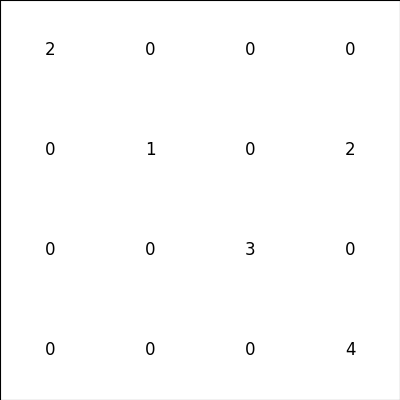

In [5]:
if not os.path.exists('frames'):
    os.makedirs('frames')
recorder = MovieGenerator("frames", "sudoku", max_frames=env.horizon)
env.set_visualizer(viz=None, movie_gen=recorder)

agent = RandomAgent(action_space=env.action_space, num_actions=env.max_allowed_actions)
agent.evaluate(env, episodes=1, render=True)
env.close()
IPyImage(filename='frames/sudoku_0.gif') 